Landfall events meeting time criteria: 464
Number of MJO active dates: 14550
Landfall events matched to MJO active days: 258


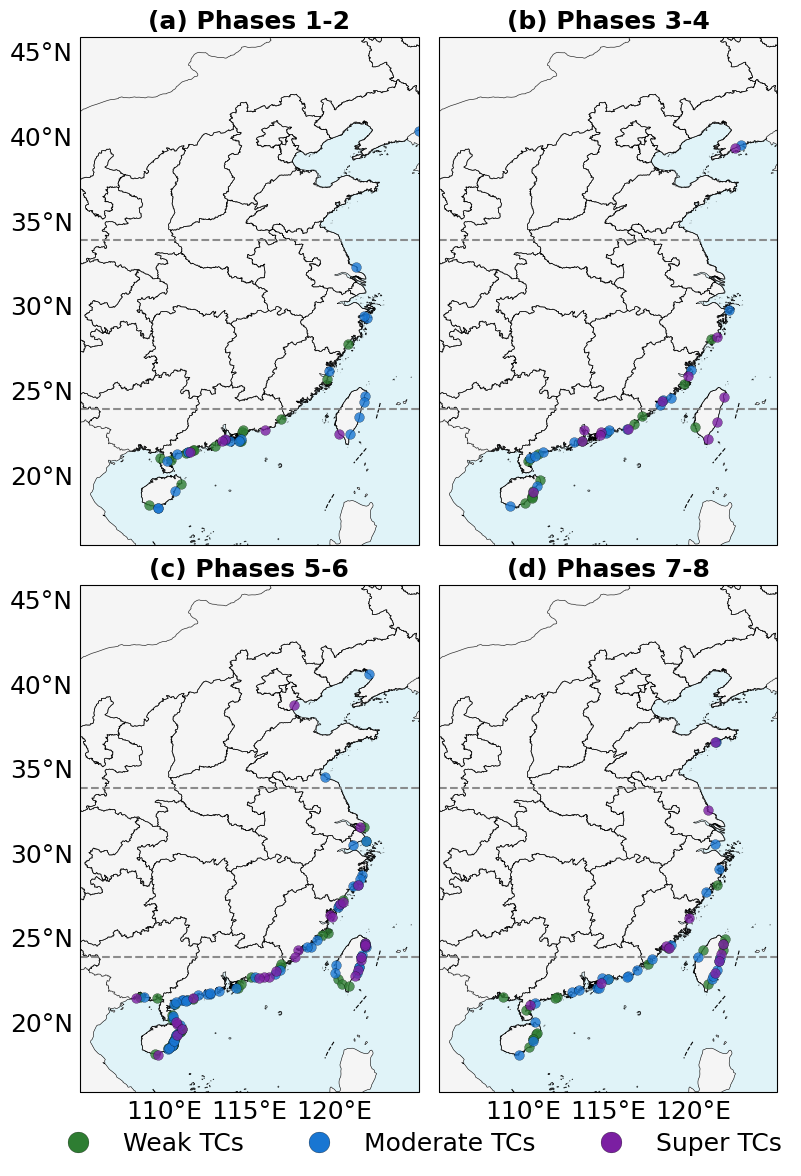

In [1]:
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.shapereader import Reader
import warnings
warnings.filterwarnings('ignore')

# ==================== Global path configuration ====================
INFO_PATH = "./typhoon_output/landfall_typhoons_info.csv"
MJO_PATH = "./ERA5 MJO (1950-2024).csv"
CHINA_SHP = "./shapefiles/china.shp"
NINE_LINE_SHP = "./shapefiles/china_nine_dotted_line.shp"

# ==================== Typhoon intensity category mapping ====================
 
CATEGORY_MAP = {1: 'Weak TCs', 2: 'Moderate TCs', 3: 'Super TCs'}

COLOR_MAP = {'Weak TCs': '#2E7D32', 'Moderate TCs': '#1976D2', 'Super TCs': '#7B1FA2'}

# ==================== MJO phase grouping function ====================
def phase_to_group(phase):
    """Map phases 1-8 to four groups"""
    if pd.isna(phase):
        return None
    p = int(phase)
    if p in [1, 2]:
        return 'Phases 1-2'
    elif p in [3, 4]:
        return 'Phases 3-4'
    elif p in [5, 6]:
        return 'Phases 5-6'
    elif p in [7, 8]:
        return 'Phases 7-8'
    else:
        return None

GROUP_ORDER = ['Phases 1-2', 'Phases 3-4', 'Phases 5-6', 'Phases 7-8']

# ==================== 1. Load and filter typhoon landfall information ====================
info_df = pd.read_csv(INFO_PATH)
info_df['code_str'] = info_df['chinese_code'].apply(lambda x: f"{x:04d}")
info_df['landfall_time'] = pd.to_datetime(info_df['landfall_time'])
info_df['landfall_date'] = info_df['landfall_time'].dt.date
info_df['year'] = info_df['landfall_time'].dt.year
info_df['month'] = info_df['landfall_time'].dt.month

# Filter: 1960–2024, June–October
mask = (info_df['year'] >= 1960) & (info_df['year'] <= 2024) & (info_df['month'].between(6, 10))
info_df = info_df[mask].copy()
print(f"Landfall events meeting time criteria: {len(info_df)}")

# Keep necessary fields, use max_wind_category for typhoon intensity classification
info_clean = info_df[['code_str', 'name', 'landfall_date', 'landfall_lat', 'landfall_lon',
                      'landfall_wind_speed', 'max_wind_category']].copy()
info_clean.rename(columns={'max_wind_category': 'typhoon_category'}, inplace=True)

# ==================== 2. Load and filter MJO data ====================
mjo_df = pd.read_csv(MJO_PATH)
mjo_df['date'] = pd.to_datetime(mjo_df['date']).dt.date

# Time range 1960–2024
mjo_df = mjo_df[(mjo_df['date'] >= pd.to_datetime('1960-01-01').date()) &
                (mjo_df['date'] <= pd.to_datetime('2024-12-31').date())]

# Keep only active events with amplitude ≥ 1
mjo_df = mjo_df[mjo_df['amplitude'] >= 1].copy()
mjo_df['phase_group'] = mjo_df['phase'].apply(phase_to_group)
mjo_df = mjo_df.dropna(subset=['phase_group'])

# Build dictionary: date → phase group (for matching)
date_to_phase = pd.Series(mjo_df['phase_group'].values, index=mjo_df['date']).to_dict()
print(f"Number of MJO active dates: {len(date_to_phase)}")

# ==================== 3. Match landfall dates with MJO ====================
info_clean['phase_group'] = info_clean['landfall_date'].map(date_to_phase)
info_clean = info_clean.dropna(subset=['phase_group'])
print(f"Landfall events matched to MJO active days: {len(info_clean)}")

# Group by phase group
grouped = {group: info_clean[info_clean['phase_group'] == group] for group in GROUP_ORDER}

# ==================== 4. Define map plotting functions (including region divider lines) ====================
def add_china_boundaries(ax):
    """Add China boundaries (including provincial borders) and nine-dotted line"""
    try:
        china = Reader(CHINA_SHP)
        ax.add_geometries(china.geometries(), ccrs.PlateCarree(),
                          facecolor='none', edgecolor='black', linewidth=0.5, alpha=0.8)
    except Exception as e:
        print(f"Failed to load China boundary file: {e}")
    try:
        nine_line = Reader(NINE_LINE_SHP)
        ax.add_geometries(nine_line.geometries(), ccrs.PlateCarree(),
                          facecolor='none', edgecolor='black', linewidth=0.8, linestyle='--')
    except Exception as e:
        print(f"Failed to load nine-dotted line file: {e}")



def add_region_dividers(ax, extent=[105, 125]):
    # Add two light gray horizontal dashed lines indicating approximate boundaries of three coastal regions
    # South China - East China boundary: approximately 24°N
    ax.plot([extent[0], extent[1]], [24, 24],
            linestyle='--', linewidth=1.5, color='gray', alpha=0.9,
            transform=ccrs.PlateCarree())
    # East China - North China boundary: approximately 34°N
    ax.plot([extent[0], extent[1]], [34, 34],
            linestyle='--', linewidth=1.5, color='gray', alpha=0.9,
            transform=ccrs.PlateCarree())

def setup_map(ax, extent=[105, 125, 16, 46]):
    """Set up basic map elements"""
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor='black')
    ax.add_feature(cfeature.LAND, facecolor='#F5F5F5')
    ax.add_feature(cfeature.OCEAN, facecolor='#E0F3F8')
    # ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.3, edgecolor='gray')

    # Add China boundaries and nine-dotted line
    add_china_boundaries(ax)

    # Add region divider lines (pass longitude range)
    add_region_dividers(ax, extent=[extent[0], extent[1]])

    # Add lat/lon gridlines
    # gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
    #                   linewidth=0.3, linestyle='--', color='gray', alpha=0.5)
    # gl.top_labels = False
    # gl.right_labels = False
    # gl.xlabel_style = {'size': 8}
    # gl.ylabel_style = {'size': 8}

# ==================== 5. Plot 4-panel map ====================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
from matplotlib.lines import Line2D

# ==================== 5. Plot 4-panel map ====================
fig, axes = plt.subplots(2, 2, figsize=(9, 13.2), sharex=True, sharey=True,
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

nrows, ncols = 2, 2
gridline_interval = 5   # Lat/lon interval, can adjust according to actual map extent

itit = ["(a) ", "(b) ", "(c) ", "(d) "]
for i, (ax, group_name, it) in enumerate(zip(axes, GROUP_ORDER, itit)):
    # Draw base map (ensure setup_map does not add gridlines inside, otherwise conflict)
    setup_map(ax, [105, 125, 16, 46])
    
    data = grouped[group_name]

    if len(data) == 0:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                ha='center', va='center', fontsize=18, color='gray')
    else:
        # Scatter plot by typhoon category
        for cat_id, cat_name in CATEGORY_MAP.items():
            subset = data[data['typhoon_category'] == cat_id]
            if len(subset) == 0:
                continue
            ax.scatter(subset['landfall_lon'], subset['landfall_lat'],
                       s=50,                       # marker size
                       c=COLOR_MAP[cat_name],
                       edgecolor='black', linewidth=0.2,
                       alpha=0.8, transform=ccrs.PlateCarree(),
                       label=cat_name, zorder=5)

    # ========== Control tick label visibility based on row/col ==========
    row = i // ncols
    col = i % ncols
    left_labels = (col == 0)           # Only first column shows left labels
    bottom_labels = (row == nrows - 1) # Only last row shows bottom labels

    # Add gridlines (only for labels, hide gridlines themselves)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                      linewidth=0, alpha=0,   # hide grid lines
                      xlocs=mticker.MultipleLocator(gridline_interval),
                      ylocs=mticker.MultipleLocator(gridline_interval))
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = left_labels
    gl.bottom_labels = bottom_labels
    # Set label font size to 18
    gl.xlabel_style = {'size': 18}
    gl.ylabel_style = {'size': 18}

    # Set subplot title (bold, fontsize 18)
    ax.set_title(it + group_name, fontsize=18, fontweight='bold')

# ========== Create custom legend handles (enlarged markers) ==========
categories = list(CATEGORY_MAP.values())
colors = [COLOR_MAP[cat] for cat in categories]

custom_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=color, markeredgecolor='black',
           markeredgewidth=0.2, markersize=15)   # legend marker size (adjustable)
    for color in colors
]

# Add global legend (placed at the bottom center)
fig.legend(custom_handles, ['Weak TCs', 'Moderate TCs', 'Super TCs'],
           loc='lower center',
           bbox_to_anchor=(0.5, 0.01),  # adjust to fit bottom margin
           ncol=3,
           fontsize=18,
           frameon=False)

# Adjust subplot spacing and bottom margin to leave room for legend
plt.subplots_adjust(hspace=0.05, wspace=0.06, bottom=0.07)

plt.savefig('2all.png', dpi=600, bbox_inches='tight')
plt.show()